# 統計検定2級レベルの実践 — EDINET データで学ぶ

このノートブックは `01_eda_basics.ipynb` の続編として、**統計検定2級の主要トピック**を
EDINET の企業×年度パネルで実践します。

## カバーする内容

| セクション | 統計2級トピック | このデータでの問い |
|---|---|---|
| 1. セットアップ | — | 必須フィルタの適用と業種分類 |
| 2. 業種別の箱ひげ図と IQR 外れ値検出 | 四分位範囲・箱ひげ図 | 業種ごとに女性管理職比率の分布はどう違う？ |
| 3. 記述統計と対数変換の必要性 | 歪度・尖度・正規化 | 売上は対数正規分布か？ |
| 4. 2 標本 t 検定 | Welch の t 検定・効果量 | 製造業と情報・通信業で女性管理職比率に有意差は？ |
| 5. 対応のある t 検定 | paired-t・Wilcoxon | 同じ企業の 2024→2025 で女性管理職比率は上昇した？ |
| 6. 単回帰分析 | 最小二乗法・決定係数・残差分析 | 売上規模で女性管理職比率を説明できる？ |

## 注意事項

- `analytics.company_year_metrics` は v0.3 以降 `(scope, worker_type)` 次元で
  1 書類あたり最大 6 行に展開されている。**必ず `scope='reporting_company' AND worker_type='all'`
  でフィルタする**（しないと同一企業が重複し、検定の p 値が不当に小さくなる＝疑似反復バイアス）。
- 業種カラム `industry` は東証 33 業種コードに準拠。「製造業」というラベルは存在しないため、
  食料品〜その他製品の **16 業種を束ねた集約カテゴリ**として扱う。


## 1. セットアップ

DuckDB から `company_year_metrics` を読み込み、**必須フィルタ**を適用してから
業種を「製造業／情報・通信業／その他」の 3 カテゴリに束ねた `industry_group` を作る。


In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 注意：seaborn の set_style は rcParams['font.family'] を 'sans-serif' に
# リセットする。日本語フォントは必ず set_style の「後」に指定する。
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Hiragino Sans'  # macOS 標準。Linux なら 'Noto Sans CJK JP' 等
plt.rcParams['axes.unicode_minus'] = False

# DuckDB に接続して必須フィルタ済みの DataFrame を取得
DB_PATH = '../artifacts/analytics/edinet_analytics.duckdb'
conn = duckdb.connect(DB_PATH, read_only=True)

df = conn.execute('''
    SELECT *
    FROM analytics.company_year_metrics
    WHERE scope = 'reporting_company' AND worker_type = 'all'
''').fetchdf()

# DECIMAL 型は object になることがあるので float に統一
for col in ['female_manager_ratio', 'male_childcare_leave_ratio', 'gender_wage_gap']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'必須フィルタ後の形状: {df.shape}')
print(f'fiscal_year の分布:')
print(df['fiscal_year'].value_counts().sort_index())


必須フィルタ後の形状: (8382, 17)
fiscal_year の分布:
fiscal_year
2021       1
2023     727
2024    4213
2025    3441
Name: count, dtype: int64


In [2]:
# 東証33業種を3カテゴリに集約
MANUFACTURING = {
    '食料品', '繊維製品', 'パルプ・紙', '化学', '医薬品', '石油・石炭製品',
    'ゴム製品', 'ガラス・土石製品', '鉄鋼', '非鉄金属', '金属製品',
    '機械', '電気機器', '輸送用機器', '精密機器', 'その他製品',
}

def to_group(industry: str | None) -> str:
    if industry in MANUFACTURING:
        return '製造業'
    if industry == '情報・通信業':
        return '情報・通信業'
    return 'その他'

df['industry_group'] = df['industry'].map(to_group)

print(df['industry_group'].value_counts())
print()
print('業種グループ × 年度の件数:')
print(pd.crosstab(df['industry_group'], df['fiscal_year']))


industry_group
その他       4197
製造業       2945
情報・通信業    1240
Name: count, dtype: int64

業種グループ × 年度の件数:
fiscal_year     2021  2023  2024  2025
industry_group                        
その他                1   313  2105  1778
情報・通信業             0   157   628   455
製造業                0   257  1480  1208


## 2. 業種別の箱ひげ図と IQR 外れ値検出

### この分析のポイント（統計2級トピック）

- **四分位数（Q1, Q2=中央値, Q3）** と **IQR = Q3 − Q1** を業種別に比較する
- **IQR 法による外れ値**：`Q1 − 1.5·IQR` 未満、または `Q3 + 1.5·IQR` を超える観測を外れ値とみなす
- 箱ひげ図は「分布の中央 50%（箱）」「ヒゲ（典型的な範囲）」「点（外れ値）」を一目で見せる

### 注意点

- 外れ値 ≠ エラー。たとえば女性管理職比率 80% の企業はベンチャーで実在する。**IQR で機械的に切る前に
  ドメイン的に妥当かを確認**するのが鉄則。
- 2024 年度に絞る（最も件数が多く、年度効果を排除できる）。


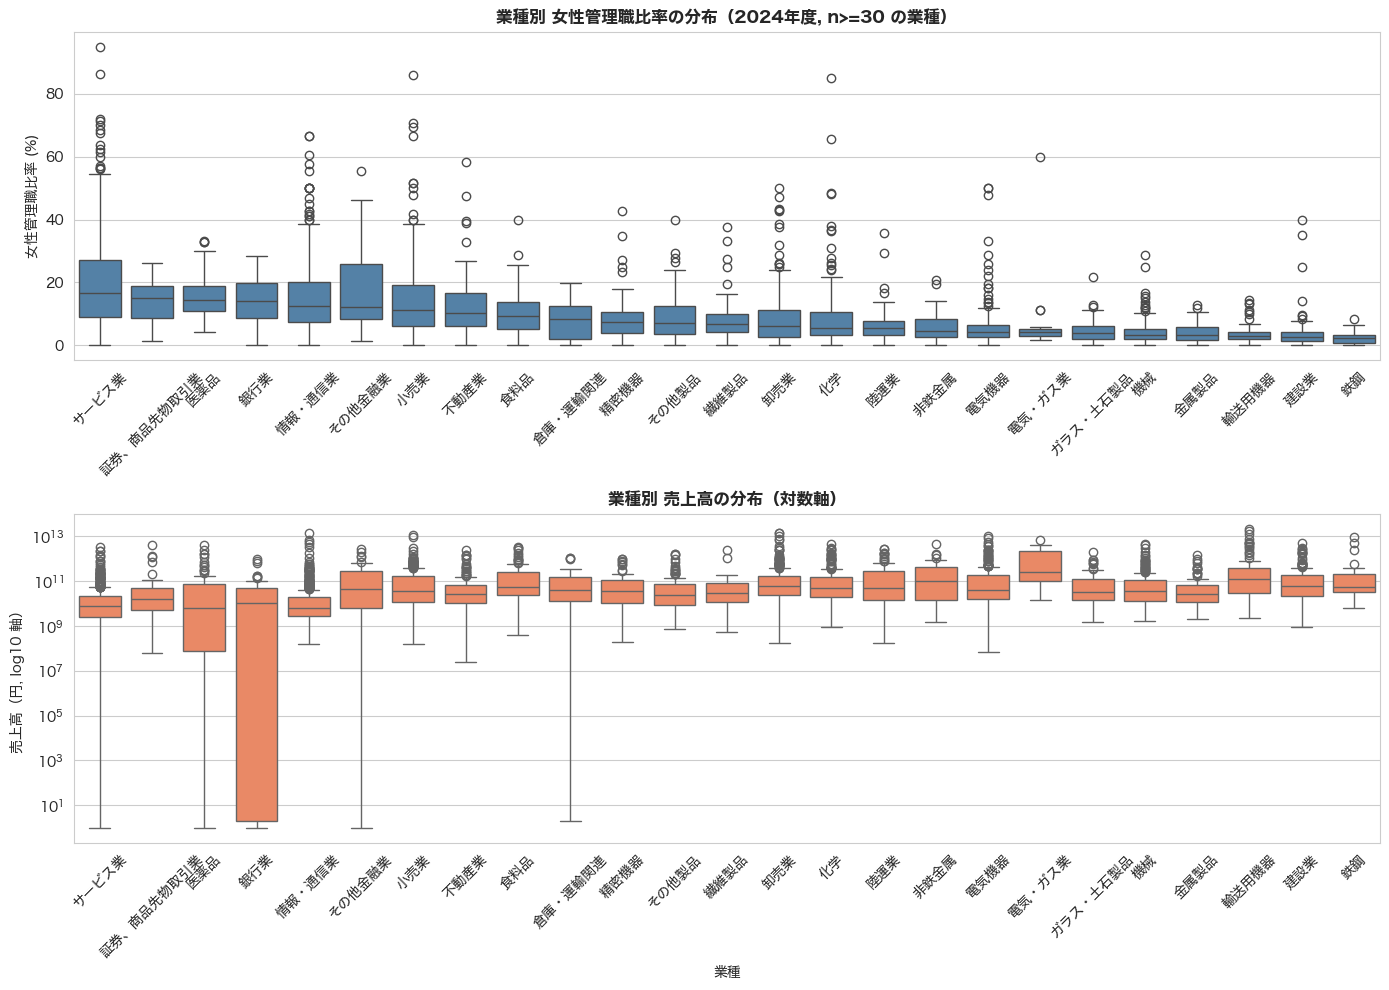

In [3]:
# 2024年度に絞り、女性管理職比率と売上それぞれを業種別に箱ひげ図化
df24 = df[(df['fiscal_year'] == 2024) & df['industry'].notna()].copy()

# 件数が一定以上ある業種のみ可視化（小さすぎる業種は箱ひげが意味を持たない）
top_industries = df24['industry'].value_counts().loc[lambda s: s >= 30].index.tolist()
df24_top = df24[df24['industry'].isin(top_industries)].copy()

# 業種ごとの中央値で並べ替え
order = (df24_top.groupby('industry')['female_manager_ratio']
         .median().sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

sns.boxplot(data=df24_top, x='industry', y='female_manager_ratio',
            order=order, ax=axes[0], color='steelblue')
axes[0].set_title('業種別 女性管理職比率の分布（2024年度, n>=30 の業種）', fontweight='bold')
axes[0].set_ylabel('女性管理職比率 (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# 売上は対数スケールで（次セクションで詳しく扱う）
sns.boxplot(data=df24_top, x='industry', y='sales',
            order=order, ax=axes[1], color='coral')
axes[1].set_yscale('log')
axes[1].set_title('業種別 売上高の分布（対数軸）', fontweight='bold')
axes[1].set_ylabel('売上高（円, log10 軸）')
axes[1].set_xlabel('業種')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../artifacts/stats_01_boxplot_by_industry.png', dpi=100, bbox_inches='tight')
plt.show()


In [4]:
# IQR 法で業種別に外れ値を数える
def iqr_outlier_summary(group: pd.Series) -> pd.Series:
    g = group.dropna()
    if len(g) < 5:
        return pd.Series({'n': len(g), 'Q1': np.nan, 'median': np.nan,
                          'Q3': np.nan, 'IQR': np.nan,
                          'lower': np.nan, 'upper': np.nan,
                          'n_outliers': np.nan, 'outlier_pct': np.nan})
    Q1, med, Q3 = g.quantile([0.25, 0.5, 0.75]).values
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = int(((g < lower) | (g > upper)).sum())
    return pd.Series({'n': len(g), 'Q1': Q1, 'median': med, 'Q3': Q3, 'IQR': IQR,
                      'lower': lower, 'upper': upper,
                      'n_outliers': n_out, 'outlier_pct': round(n_out / len(g) * 100, 1)})

summary = (df24_top.groupby('industry')['female_manager_ratio']
           .apply(iqr_outlier_summary).unstack()
           .sort_values('median', ascending=False))
print('【業種別 女性管理職比率の四分位と外れ値】')
print(summary.round(2))


【業種別 女性管理職比率の四分位と外れ値】
                n     Q1  median     Q3    IQR  lower  upper  n_outliers  \
industry                                                                   
サービス業       356.0   9.07   16.55  27.30  18.23 -18.26  54.64        15.0   
証券、商品先物取引業   18.0   8.78   15.20  18.80  10.02  -6.26  33.84         0.0   
医薬品          43.0  11.05   14.50  18.75   7.70  -0.50  30.30         3.0   
銀行業          64.0   8.60   14.05  19.95  11.35  -8.42  36.97         0.0   
情報・通信業      356.0   7.50   12.60  20.02  12.52 -11.29  38.81        19.0   
その他金融業       32.0   8.50   12.05  25.82  17.32 -17.49  51.81         1.0   
小売業         174.0   6.12   11.10  19.25  13.12 -13.56  38.94        11.0   
不動産業         74.0   6.00   10.37  16.65  10.65  -9.97  32.62         5.0   
食料品         103.0   5.35    9.20  13.80   8.45  -7.33  26.48         2.0   
倉庫・運輸関連      28.0   2.00    8.35  12.65  10.65 -13.98  28.62         0.0   
精密機器         37.0   3.80    7.40  10.70   6.90  -6.55  21.05      

In [5]:
# 「外れ値」と判定された企業を具体的に見る（情報・通信業の上側外れ値）
target_industry = '情報・通信業'
g = df24[df24['industry'] == target_industry]['female_manager_ratio'].dropna()
Q1, Q3 = g.quantile([0.25, 0.75])
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

outlier_rows = (df24[(df24['industry'] == target_industry) &
                    (df24['female_manager_ratio'] > upper)]
                [['company_name', 'female_manager_ratio', 'sales', 'employee_count']]
                .sort_values('female_manager_ratio', ascending=False)
                .head(10))

print(f'【{target_industry}】 上側外れ値の閾値: {upper:.2f}%')
print(f'外れ値とされた上位10社:')
print(outlier_rows.to_string(index=False))


【情報・通信業】 上側外れ値の閾値: 38.81%
外れ値とされた上位10社:
     company_name  female_manager_ratio       sales  employee_count
  ＭＩＴホールディングス株式会社                 66.70  5240301000             398
      ＵＬＳグループ株式会社                 66.70 10382000000             597
        株式会社ボルテージ                 60.70  3456700000             165
株式会社エイチームホールディングス                 57.55 23917000000             813
       株式会社アイスタイル                 55.40 56085000000            1079
 ＪＢＣＣホールディングス株式会社                 50.00 65194000000            1626
       株式会社フォーサイド                 50.00  5340241000              55
    ジェイフロンティア株式会社                 50.00 17714904000             315
 株式会社ソフィアホールディングス                 50.00  9031734000             193
     株式会社ワイヤレスゲート                 50.00  8462593000              32


**読み方のヒント：**

- 中央値が業種でどれくらい違うか、箱の高さ（IQR の大きさ）でばらつきがどう違うかを比較する
- 「上側外れ値」とされた企業がベンチャーや女性活躍推進に力を入れている企業ならドメイン的に妥当
- 「製造業」と「情報・通信業」では女性管理職比率の中央値が大きく違うか？ → これが次の 2 標本 t 検定の動機


## 3. 記述統計と対数変換の必要性

### この分析のポイント（統計2級トピック）

- **歪度（skewness）**：分布の左右非対称性。`> 0` なら右に裾が長い、`< 0` なら左に裾が長い
- **尖度（kurtosis）**：分布の尖り具合。正規分布で 0（pandas の `kurt()` は超過尖度）
- **対数変換**：右裾の長い分布（売上、所得、人口など）は `log(x+1)` で正規分布に近づくことが多い
- **QQ プロット**：観測値の分位点を理論分布（正規）の分位点と比べる視覚的検定

### このデータでの問い

売上は明らかに右に裾が長い（数社のメガ企業がいるから）。**対数を取ると正規分布に近づくか？**
近づけば、その後の検定や回帰で「正規性の仮定」を満たすために log を取る正当化ができる。


In [6]:
# 売上の歪度・尖度を、元のスケール vs log スケールで比較
sales_raw = df24['sales'].dropna()
sales_log = np.log1p(sales_raw)  # log(1+x) でゼロや小さい値にも対応

def stat_table(s: pd.Series, label: str) -> pd.Series:
    return pd.Series({
        'n': len(s),
        'mean': s.mean(),
        'median': s.median(),
        'std': s.std(ddof=1),
        'skewness': stats.skew(s, bias=False),
        'kurtosis(excess)': stats.kurtosis(s, bias=False),
    }, name=label)

table = pd.concat([
    stat_table(sales_raw, 'sales (raw)'),
    stat_table(sales_log, 'log(1+sales)'),
], axis=1)
print(table.round(3))


                   sales (raw)  log(1+sales)
n                 4.211000e+03      4211.000
mean              2.121937e+11        23.716
median            2.467000e+10        23.929
std               9.037068e+11         3.315
skewness          1.139800e+01        -4.226
kurtosis(excess)  1.722250e+02        27.495


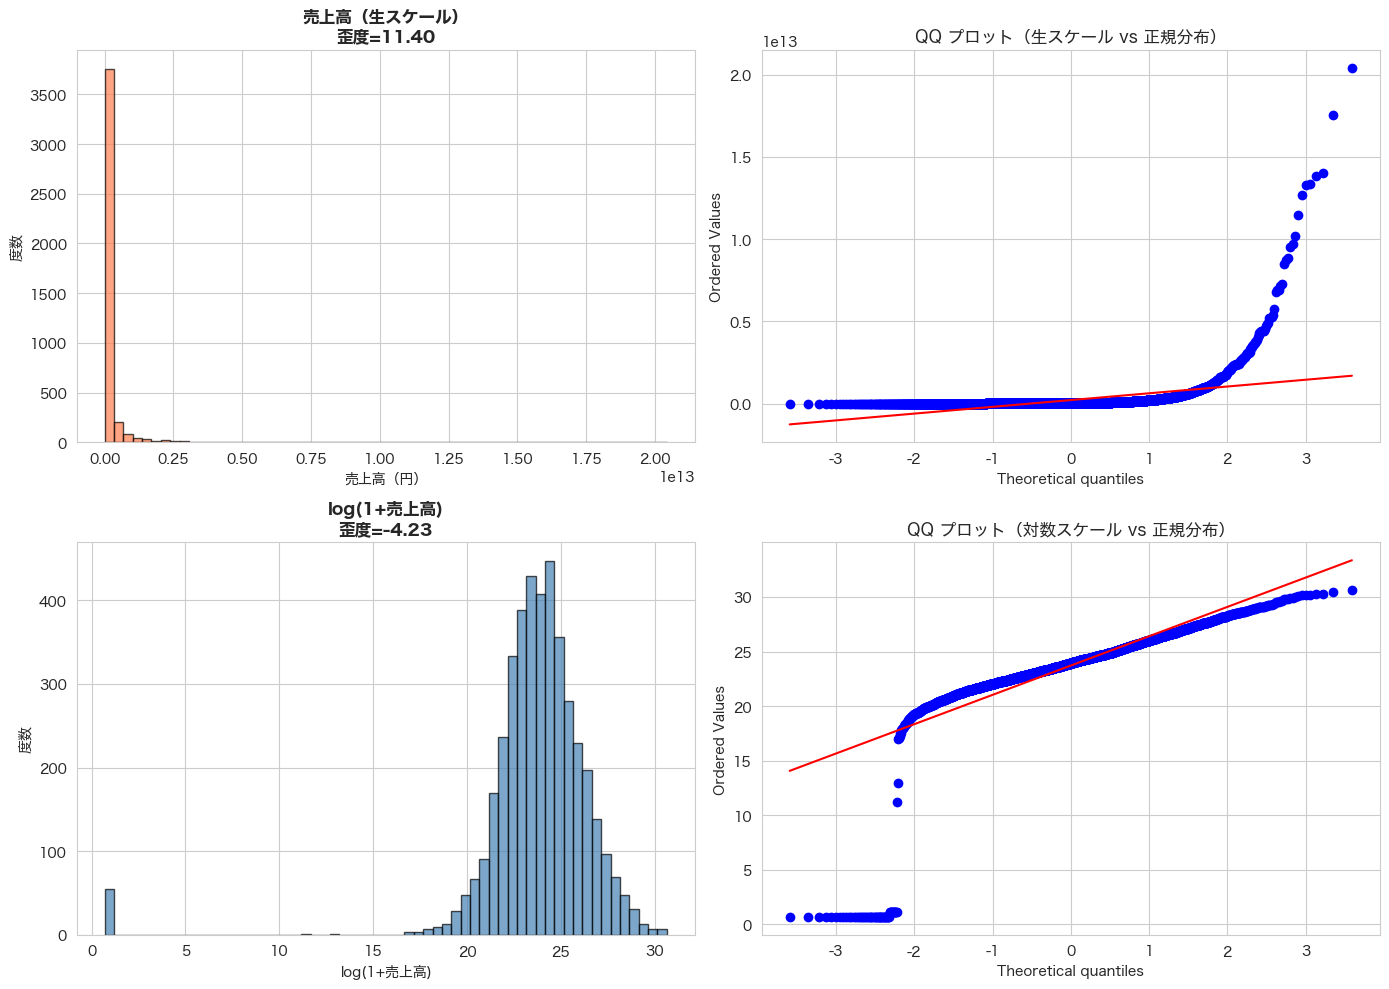

In [7]:
# ヒストグラム + QQ プロットで「log でどれくらい正規分布に近づくか」を見る
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 上段：raw sales
axes[0, 0].hist(sales_raw, bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[0, 0].set_title(f'売上高（生スケール）\n歪度={stats.skew(sales_raw, bias=False):.2f}',
                     fontweight='bold')
axes[0, 0].set_xlabel('売上高（円）')
axes[0, 0].set_ylabel('度数')

stats.probplot(sales_raw, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('QQ プロット（生スケール vs 正規分布）')

# 下段：log sales
axes[1, 0].hist(sales_log, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_title(f'log(1+売上高)\n歪度={stats.skew(sales_log, bias=False):.2f}',
                     fontweight='bold')
axes[1, 0].set_xlabel('log(1+売上高)')
axes[1, 0].set_ylabel('度数')

stats.probplot(sales_log, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('QQ プロット（対数スケール vs 正規分布）')

plt.tight_layout()
plt.savefig('../artifacts/stats_02_log_transform.png', dpi=100, bbox_inches='tight')
plt.show()


**読み方のヒント：**

- 生スケールの歪度は **数十** クラスになるはず → 平均値はメガ企業に引っ張られて代表値にならない
- 対数を取ると歪度が **±1 程度** に収まり、QQ プロットの点が直線に近づく → 「対数を取れば正規分布に近い」
- 以降の回帰分析で `log(1+sales)` を説明変数に使う根拠がこれ

**統計2級の用語整理：**

| 用語 | 意味 |
|---|---|
| 標本歪度（bias=False） | 不偏推定量（自由度補正あり）。SciPy のデフォルトは bias=True |
| 標本超過尖度 | 正規分布を基準値 0 とする尖度。`scipy.stats.kurtosis` のデフォルト |
| QQ プロット | y=x の直線に近いほど、想定した理論分布に従っている |


## 4. 2 標本 t 検定：製造業 vs 情報・通信業

### 仮説

- 帰無仮説 H₀: 製造業と情報・通信業で、女性管理職比率の **母平均は等しい**
- 対立仮説 H₁: **母平均は異なる**（両側検定）

### 使う手法（統計2級の中核）

1. **正規性チェック**：両群の分布を箱ひげ／ヒストグラムで確認
2. **等分散検定**：Levene 検定（→ 等分散かで t 検定の式が変わる）
3. **2 標本 t 検定**：等分散なら Student の t、不等分散なら **Welch の t 検定**
4. **効果量（Cohen's d）**：「統計的有意」と「実質的に意味のある差」を区別

### このデータ特有の落とし穴

- 同じ企業が複数年度に出現する → 独立性が壊れる。**2024 年度1枚に絞る**ことで1社1観測に


製造業: n=1066, mean=7.06, std=7.74
情報・通信業: n=356, mean=15.66, std=11.63


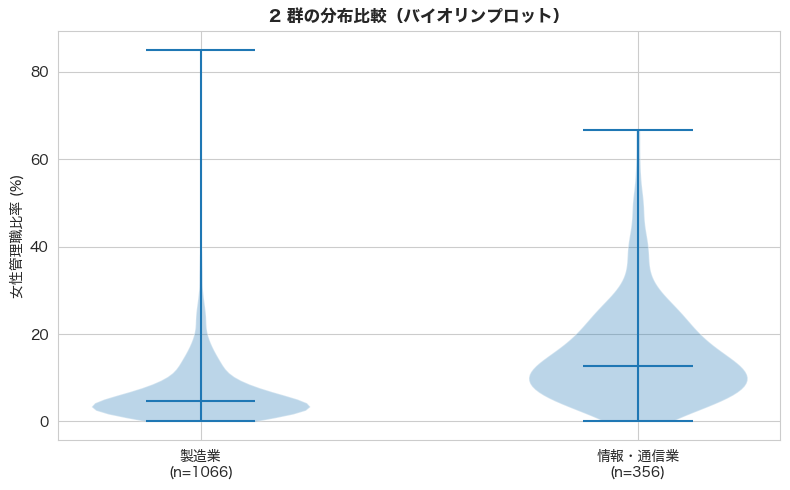

In [8]:
# 2群を抽出（2024年度のみ）
g_mfg = df24[df24['industry_group'] == '製造業']['female_manager_ratio'].dropna()
g_ict = df24[df24['industry_group'] == '情報・通信業']['female_manager_ratio'].dropna()

print(f'製造業: n={len(g_mfg)}, mean={g_mfg.mean():.2f}, std={g_mfg.std(ddof=1):.2f}')
print(f'情報・通信業: n={len(g_ict)}, mean={g_ict.mean():.2f}, std={g_ict.std(ddof=1):.2f}')

# 可視化（分布を視覚的に比較）
fig, ax = plt.subplots(figsize=(8, 5))
parts = ax.violinplot([g_mfg, g_ict], showmedians=True, showmeans=False)
ax.set_xticks([1, 2])
ax.set_xticklabels([f'製造業\n(n={len(g_mfg)})', f'情報・通信業\n(n={len(g_ict)})'])
ax.set_ylabel('女性管理職比率 (%)')
ax.set_title('2 群の分布比較（バイオリンプロット）', fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/stats_03_ttest_groups.png', dpi=100, bbox_inches='tight')
plt.show()


In [9]:
# Step1: Levene 検定で等分散性を確認
levene_stat, levene_p = stats.levene(g_mfg, g_ict, center='median')
print(f'【Levene 検定】 W = {levene_stat:.3f}, p = {levene_p:.4f}')
if levene_p < 0.05:
    print('→ p < 0.05 のため等分散仮説を棄却。Welch の t 検定を使う')
else:
    print('→ 等分散仮説を棄却できない。Student の t 検定でもよいが、保険として Welch を使うのが標準')

# Step2: Welch の t 検定（等分散仮定なし、安全側）
t_stat, t_p = stats.ttest_ind(g_mfg, g_ict, equal_var=False)
print()
print(f'【Welch の 2 標本 t 検定（両側）】')
print(f'  t 統計量 = {t_stat:.3f}')
print(f'  p 値     = {t_p:.6f}')
print(f'  自由度（Welch–Satterthwaite 近似）= 表示は scipy.stats.ttest_ind_from_stats で確認可')

# Step3: 効果量（Cohen's d）
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    # プールされた標準偏差
    pooled = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled

d = cohens_d(g_mfg, g_ict)
print(f'\n【効果量 Cohen\'s d】 = {d:.3f}')
print('  目安: |d| < 0.2 小, 0.2-0.5 中, 0.5-0.8 大, > 0.8 非常に大')

# Step4: 平均の差の 95% 信頼区間
diff = g_mfg.mean() - g_ict.mean()
se = np.sqrt(g_mfg.var(ddof=1)/len(g_mfg) + g_ict.var(ddof=1)/len(g_ict))
# Welch–Satterthwaite df
df_w = (g_mfg.var(ddof=1)/len(g_mfg) + g_ict.var(ddof=1)/len(g_ict))**2 / (
    (g_mfg.var(ddof=1)/len(g_mfg))**2/(len(g_mfg)-1) +
    (g_ict.var(ddof=1)/len(g_ict))**2/(len(g_ict)-1))
tcrit = stats.t.ppf(0.975, df_w)
ci_low, ci_high = diff - tcrit * se, diff + tcrit * se
print(f'\n【平均差の 95% 信頼区間】 {diff:.2f} ± {tcrit*se:.2f}')
print(f'  → [{ci_low:.2f}, {ci_high:.2f}] (製造業 − 情報・通信業)')


【Levene 検定】 W = 70.731, p = 0.0000
→ p < 0.05 のため等分散仮説を棄却。Welch の t 検定を使う

【Welch の 2 標本 t 検定（両側）】
  t 統計量 = -13.016
  p 値     = 0.000000
  自由度（Welch–Satterthwaite 近似）= 表示は scipy.stats.ttest_ind_from_stats で確認可

【効果量 Cohen's d】 = -0.968
  目安: |d| < 0.2 小, 0.2-0.5 中, 0.5-0.8 大, > 0.8 非常に大

【平均差の 95% 信頼区間】 -8.60 ± 1.30
  → [-9.89, -7.30] (製造業 − 情報・通信業)


**読み方のヒント：**

- **p 値だけ見て満足しない**。n が 200 を超えると小さい差でも有意になる。だから Cohen's d で
  「実質的に意味のある差か」を必ず併記する。
- **信頼区間が 0 を含まない** → 平均差が有意（両側 5%）。これは p < 0.05 と等価。
- もし「製造業のほうが低い」という方向の仮説が事前にあるなら、**片側検定**にすることで検出力が
  上がる。ただし結果を見てから片側に切り替えるのは p-hacking なので NG。


## 5. 対応のある t 検定：同一企業の 2024 → 2025

### なぜ「対応のある」を使うのか

セクション 4 の独立 2 標本 t 検定は「製造業 100 社 vs 情報・通信業 100 社」のように **異なる個体の比較**。
今回は同じ企業 A 社の 2024 年と 2025 年なので、**個体間のばらつき（社風など）をキャンセル**できる。

数式的には「差 d_i = X_2025_i − X_2024_i」の 1 標本 t 検定（H₀: μ_d = 0）と等価。

### 手法

1. ピボットして同一企業の 2 年分を 1 行に
2. 差の正規性を確認（QQ プロット）
3. **paired t 検定**（正規性 OK の場合）
4. **Wilcoxon 符号付き順位検定**（ノンパラ版、正規性が崩れていても使える）


In [10]:
# 2024 と 2025 の両方に女性管理職比率がある企業をピボット
paired = (df[df['fiscal_year'].isin([2024, 2025])]
          .pivot_table(index='edinet_code', columns='fiscal_year',
                       values='female_manager_ratio', aggfunc='first')
          .dropna())
paired.columns = [f'y{c}' for c in paired.columns]
paired['diff'] = paired['y2025'] - paired['y2024']

print(f'ペアが取れた企業数: {len(paired)}')
print()
print('【差の記述統計】')
print(paired['diff'].describe().round(3))


ペアが取れた企業数: 2066

【差の記述統計】
count    2066.000
mean        0.806
std         4.241
min       -72.000
25%        -0.100
50%         0.400
75%         1.500
max        44.700
Name: diff, dtype: float64


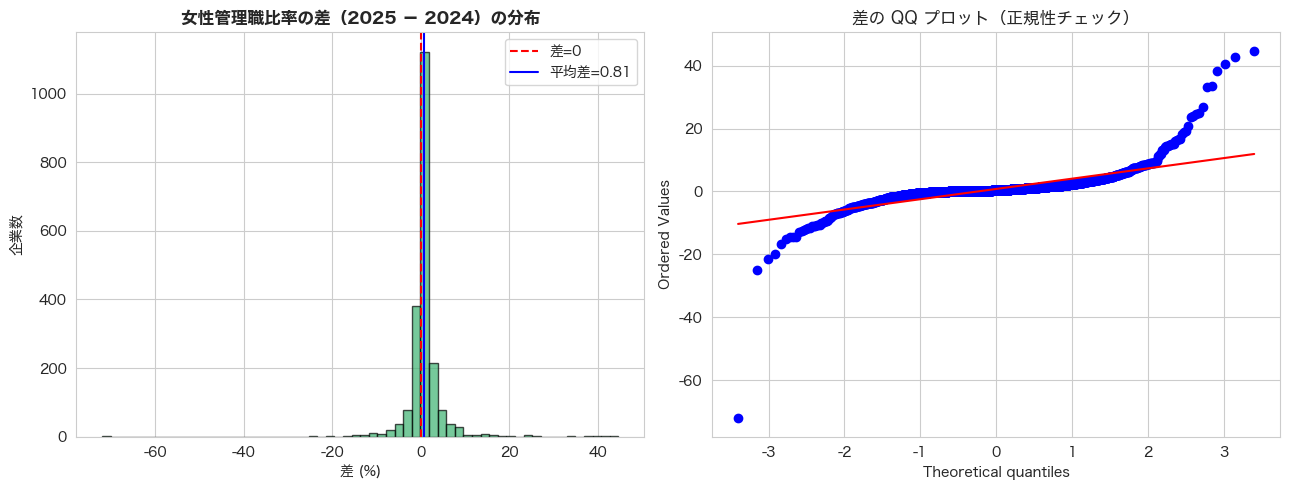

In [11]:
# 差の分布を可視化（正規性チェック）
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(paired['diff'], bins=60, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', label='差=0')
axes[0].axvline(paired['diff'].mean(), color='blue', linestyle='-',
                label=f'平均差={paired["diff"].mean():.2f}')
axes[0].set_title('女性管理職比率の差（2025 − 2024）の分布', fontweight='bold')
axes[0].set_xlabel('差 (%)')
axes[0].set_ylabel('企業数')
axes[0].legend()

stats.probplot(paired['diff'], dist='norm', plot=axes[1])
axes[1].set_title('差の QQ プロット（正規性チェック）')

plt.tight_layout()
plt.savefig('../artifacts/stats_04_paired_diff.png', dpi=100, bbox_inches='tight')
plt.show()


In [12]:
# 対応のある t 検定（paired t-test）
t_stat, t_p = stats.ttest_rel(paired['y2025'], paired['y2024'])
print(f'【対応のある t 検定】')
print(f'  H0: 2024 と 2025 で女性管理職比率の母平均は等しい')
print(f'  t = {t_stat:.3f}, p = {t_p:.6f}')

# Wilcoxon 符号付き順位検定（差の分布が正規でない場合の代替）
w_stat, w_p = stats.wilcoxon(paired['y2025'], paired['y2024'])
print(f'\n【Wilcoxon 符号付き順位検定】（ノンパラ）')
print(f'  W = {w_stat:.3f}, p = {w_p:.6f}')

# 差の効果量（Cohen's d_z = 平均差 / 差の標準偏差）
dz = paired['diff'].mean() / paired['diff'].std(ddof=1)
print(f'\n【対応のある効果量 d_z】 = {dz:.3f}')

# 差の 95% 信頼区間
n = len(paired)
se = paired['diff'].std(ddof=1) / np.sqrt(n)
tcrit = stats.t.ppf(0.975, n - 1)
mean_d = paired['diff'].mean()
print(f'\n【平均差の 95% 信頼区間】 {mean_d:.3f} ± {tcrit*se:.3f}')
print(f'  → [{mean_d - tcrit*se:.3f}, {mean_d + tcrit*se:.3f}]')
print(f'  (正の値 = 2025 のほうが平均的に高い)')


【対応のある t 検定】
  H0: 2024 と 2025 で女性管理職比率の母平均は等しい
  t = 8.644, p = 0.000000

【Wilcoxon 符号付き順位検定】（ノンパラ）
  W = 461590.500, p = 0.000000

【対応のある効果量 d_z】 = 0.190

【平均差の 95% 信頼区間】 0.806 ± 0.183
  → [0.623, 0.989]
  (正の値 = 2025 のほうが平均的に高い)


**読み方のヒント：**

- t 検定と Wilcoxon の **両方で同じ結論**になるなら、結果はかなり頑健と言える
- 「平均差 +0.X%」のように差が小さくても、n が 2000 を超えると有意になる。**社会的に意味のある
  変化幅か** を Cohen's d_z や信頼区間で評価する（d_z < 0.2 は実質的にはほぼゼロ）
- 「同一企業内での比較」だからこそ、業種構成の違いや企業規模の影響をキャンセルできる


## 6. 単回帰分析：log(売上) → 女性管理職比率

### この分析のポイント（統計2級の到達点）

「企業規模が大きいほど、女性管理職比率は高い／低い」という仮説を **定量化**する。

**モデル：** `female_manager_ratio = β₀ + β₁ · log(1 + sales) + ε`

| 統計量 | 意味 |
|---|---|
| 回帰係数 β₁ | log 売上が 1 単位（= 売上 e ≈ 2.7 倍）増えるとき、比率が何 % 動くか |
| 決定係数 R² | 全変動のうち、回帰直線で説明できる割合 |
| 係数の t 検定 | β₁ = 0 という帰無仮説を棄却できるか |
| 残差プロット | 線形性・等分散性（homoskedasticity）の確認 |

### 注意

- 単回帰の結果から「規模を増やせば女性管理職が増える」と言ってはいけない（**相関 ≠ 因果**）
- 残差に明らかな曲線パターンが残るなら、変数変換や多項式項を追加する


In [13]:
# 回帰用のデータセットを準備（2024年度・両変数欠損なし）
reg_df = (df24[['sales', 'female_manager_ratio', 'industry_group']]
          .dropna()
          .assign(log_sales=lambda x: np.log1p(x['sales']))
          .reset_index(drop=True))

print(f'回帰用サンプル数: {len(reg_df)}')

# statsmodels で OLS 推定
model = smf.ols('female_manager_ratio ~ log_sales', data=reg_df).fit()
print(model.summary())


回帰用サンプル数: 2604
                             OLS Regression Results                             
Dep. Variable:     female_manager_ratio   R-squared:                       0.038
Model:                              OLS   Adj. R-squared:                  0.038
Method:                   Least Squares   F-statistic:                     104.0
Date:                  Mon, 18 May 2026   Prob (F-statistic):           5.68e-24
Time:                          02:56:37   Log-Likelihood:                -10041.
No. Observations:                  2604   AIC:                         2.009e+04
Df Residuals:                      2602   BIC:                         2.010e+04
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     31.

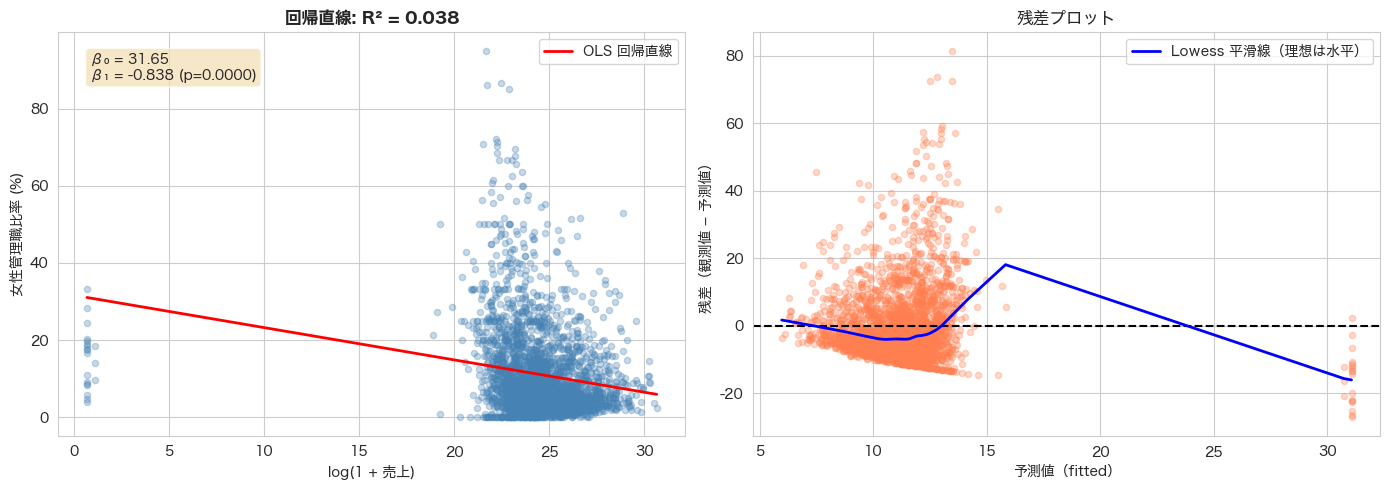

In [14]:
# 散布図に回帰直線を重ねて視覚化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：散布図 + 回帰直線
ax = axes[0]
ax.scatter(reg_df['log_sales'], reg_df['female_manager_ratio'],
           alpha=0.3, s=20, color='steelblue')

# 回帰直線を描画
xline = np.linspace(reg_df['log_sales'].min(), reg_df['log_sales'].max(), 100)
yline = model.params['Intercept'] + model.params['log_sales'] * xline
ax.plot(xline, yline, color='red', linewidth=2, label='OLS 回帰直線')

ax.set_xlabel('log(1 + 売上)')
ax.set_ylabel('女性管理職比率 (%)')
ax.set_title(f'回帰直線: R² = {model.rsquared:.3f}', fontweight='bold')
ax.text(0.05, 0.95,
        f"β₀ = {model.params['Intercept']:.2f}\n"
        f"β₁ = {model.params['log_sales']:.3f} (p={model.pvalues['log_sales']:.4f})",
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
ax.legend()

# 右：残差プロット（線形性・等分散性のチェック）
ax = axes[1]
ax.scatter(model.fittedvalues, model.resid, alpha=0.3, s=20, color='coral')
ax.axhline(0, color='black', linestyle='--')
ax.set_xlabel('予測値（fitted）')
ax.set_ylabel('残差（観測値 − 予測値）')
ax.set_title('残差プロット')
# Lowess（局所平滑化）で残差トレンドを可視化
from statsmodels.nonparametric.smoothers_lowess import lowess
sm_line = lowess(model.resid, model.fittedvalues, frac=0.3, return_sorted=True)
ax.plot(sm_line[:, 0], sm_line[:, 1], color='blue', linewidth=2,
        label='Lowess 平滑線（理想は水平）')
ax.legend()

plt.tight_layout()
plt.savefig('../artifacts/stats_05_regression.png', dpi=100, bbox_inches='tight')
plt.show()


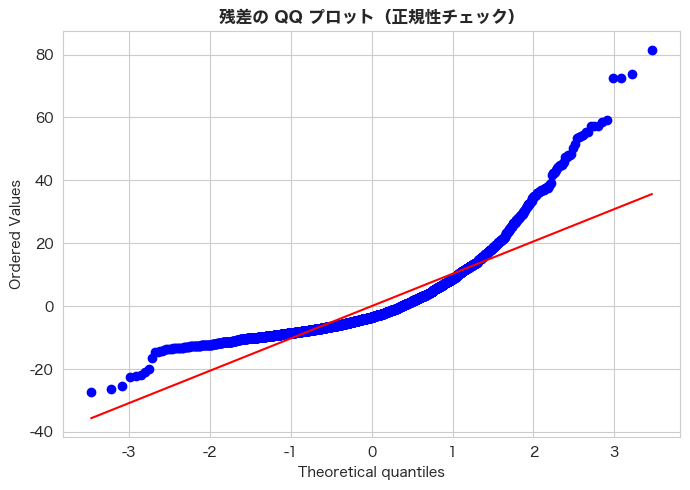

【summary() の読みどころ】
  • R-squared       = 0.0384  ← log売上で説明できる比率分散の割合
  • F-statistic p   = 5.6846e-24  ← モデル全体の有意性（H0: 全係数=0）
  • β1 の p 値      = 5.6846e-24  ← 個別係数の有意性
  • β1 の 95% CI    = [-0.9988075768542419, -0.6766474668994669]


In [15]:
# 残差の QQ プロットで正規性をチェック
fig, ax = plt.subplots(figsize=(7, 5))
stats.probplot(model.resid, dist='norm', plot=ax)
ax.set_title('残差の QQ プロット（正規性チェック）', fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/stats_06_resid_qq.png', dpi=100, bbox_inches='tight')
plt.show()

print('【summary() の読みどころ】')
print(f"  • R-squared       = {model.rsquared:.4f}  ← log売上で説明できる比率分散の割合")
print(f"  • F-statistic p   = {model.f_pvalue:.4e}  ← モデル全体の有意性（H0: 全係数=0）")
print(f"  • β1 の p 値      = {model.pvalues['log_sales']:.4e}  ← 個別係数の有意性")
print(f"  • β1 の 95% CI    = {model.conf_int().loc['log_sales'].tolist()}")


**読み方のヒント（統計2級の到達点）：**

- **R² が低い**（例: 0.05）= 説明力はわずか。「規模だけでは比率を予測できない」ことを意味する
- **β₁ が有意でも R² が低い**ことはよくある。これは「効果は確かにあるが、ばらつきの大半は他の要因」と読む
- **残差プロットで Lowess 線が水平でない** → 線形仮定が崩れている可能性。多項式や別の変換を試す
- **残差 QQ プロットが直線から外れる** → 誤差の正規性が崩れている。p 値の正確性に影響

### 統計2級的に「次に何ができるか」

- **重回帰**：`log売上 + 業種ダミー + 年度` を同時に入れて、業種で交絡を制御
- **多重共線性（VIF）**：説明変数同士が強く相関すると係数が不安定化
- **ANOVA（分散分析）**：複数業種カテゴリの効果を一度に検定
- **カイ二乗検定**：「業種 × 女性管理職比率の高低」の独立性を検定


## まとめ — 統計2級トピックとこのデータの対応関係

| 章 | 学んだこと | キー関数 |
|---|---|---|
| 2 | 業種別の **四分位・IQR・外れ値** | `Series.quantile`, `boxplot` |
| 3 | **歪度・尖度** で対数変換の必要性を判断、**QQ プロット**で正規性をチェック | `scipy.stats.skew/kurtosis/probplot` |
| 4 | **Levene 検定 + Welch の t 検定 + Cohen's d** で独立2群比較 | `scipy.stats.levene/ttest_ind` |
| 5 | **対応のある t 検定 + Wilcoxon** で同一個体の前後比較 | `scipy.stats.ttest_rel/wilcoxon` |
| 6 | **OLS 単回帰**（R²・係数の t 検定・残差分析） | `statsmodels.formula.api.ols` |

### このNotebookで意識した「2級の落とし穴」

1. **疑似反復（pseudo-replication）**：scope/worker_type で重複行が出る → 必須フィルタ
2. **片側 vs 両側**：仮説を見てから方向を決めない（p-hacking）
3. **p 値だけで判断しない**：効果量・信頼区間と併記
4. **正規性の確認は QQ プロットで視覚的に**：Shapiro-Wilk は n が大きいと過剰に棄却する
5. **相関 ≠ 因果**：単回帰は説明変数と目的変数の関連を示すだけ
